## SOLAR IRRADIATION




In [1]:

import geopandas as gpd
import pandas as pd


#Read in shapefile tags
#(1) reading in raster data
shp = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data/G02-22_5942-jgd_GML 2/G02-22_5942-jgd.shp") #Reading in irradiation data


In [2]:
shp.head()

,G02_001,G02_002,G02_003,G02_004,G02_005,G02_006,G02_007,G02_008,G02_009,G02_010,...,G02_076,G02_077,G02_078,G02_079,G02_080,G02_081,G02_082,G02_083,G02_084,geometry
0,59420090,403,244,736,927,1156,1289,1609,1687,2038,...,184,180,171,163,131,103,80,67,131,"POLYGON ((142 39.40833, 142 39.41667, 142.0125..."
1,59420092,395,192,720,921,1155,1275,1590,1655,2003,...,187,179,171,164,131,103,80,67,131,"POLYGON ((142.025 39.40833, 142.025 39.41667, ..."
2,59421000,408,249,735,901,1155,1286,1621,1701,2042,...,185,180,172,163,131,104,79,68,132,"POLYGON ((142 39.41667, 142 39.425, 142.0125 3..."
3,59421001,404,214,730,898,1158,1279,1605,1679,2027,...,187,180,172,164,131,103,79,68,132,"POLYGON ((142.0125 39.41667, 142.0125 39.425, ..."
4,59421002,399,183,719,894,1157,1272,1592,1659,2008,...,189,182,173,166,132,104,80,68,133,"POLYGON ((142.025 39.41667, 142.025 39.425, 14..."


DATA PROCESSING FOR SOLAR RADIATION

for solar irradiation data, data from https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-G02-v3_0.html was dowloaded with the region of HOKKAIDO for testing.
all the Meshes needs to be combined in one data frame. 

this dataset contains rainfall, temperature, snowfall, sunshine hours per month, radiation per month and global solar radiation. We will most likely keep only the column Annual average global solar radiation
(G02_084) for our model. 

In [25]:
#COMBINE ALL MESHES INTO ONE DATAFRAME . 

import geopandas as gpd
import pandas as pd
import os


In [3]:

# 1. Define the root folder
data_folder = '/fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido'

# 2. Initialize an empty list to collect GDFs
gdfs = []

# 3. Walk through all subfolders and files
for root, dirs, files in os.walk(data_folder):
    for file in files:
        if file.endswith('.GML') or file.endswith('.shp'):
            file_path = os.path.join(root, file)
            try:
                gdf = gpd.read_file(file_path)
                gdfs.append(gdf)
                print(f"Loaded: {file_path}")
            except Exception as e:
                print(f"Failed to read {file_path} due to {e}")

# 4. Merge all files into one GeoDataFrame
merged_gdf = pd.concat(gdfs, ignore_index=True)

# 5. Check the data
print(merged_gdf.head())
print(merged_gdf.columns)


Loaded: /fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido/G02-22_6848-jgd_GML/G02-22_6848-jgd.shp
Loaded: /fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido/G02-22_6747-jgd_GML/G02-22_6747-jgd.shp
Loaded: /fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido/G02-22_6748-jgd_GML/G02-22_6748-jgd.shp
Loaded: /fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido/G02-22_6840-jgd_GML/G02-22_6840-jgd.shp
Loaded: /fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido/G02-22_6841-jgd_GML/G02-22_6841-jgd.shp
Loaded: /fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido/G02-22_6842-jgd_GML/G02-22_6842-jgd.shp
Loaded: /fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido/G02-22_6847-jgd_GML/G02-22_6847-jgd.shp
Loaded: /fs9/eliviau/hex2vec_project/Eli_test/datatest/irradiation_data_Hokkaido/G02-22_6647-jgd_GML/G02-22_6647-jgd.shp
Loaded: /fs9/eliviau/hex2vec_pro

In [12]:
merged_gdf.head()

,G02_001,G02_002,G02_003,G02_004,G02_005,G02_006,G02_007,G02_008,G02_009,G02_010,...,G02_076,G02_077,G02_078,G02_079,G02_080,G02_081,G02_082,G02_083,G02_084,geometry
0,68480000,999999,999999,999999,999999,999999,999999,999999,999999,999999,...,999999,999999,999999,999999,999999,999999,999999,999999,999999,"POLYGON ((148 45.33333, 148 45.34167, 148.0125..."
1,68480303,999999,999999,999999,999999,999999,999999,999999,999999,999999,...,999999,999999,999999,999999,999999,999999,999999,999999,999999,"POLYGON ((148.4125 45.33333, 148.4125 45.34167..."
2,68480304,999999,999999,999999,999999,999999,999999,999999,999999,999999,...,999999,999999,999999,999999,999999,999999,999999,999999,999999,"POLYGON ((148.425 45.33333, 148.425 45.34167, ..."
3,68480305,999999,999999,999999,999999,999999,999999,999999,999999,999999,...,999999,999999,999999,999999,999999,999999,999999,999999,999999,"POLYGON ((148.4375 45.33333, 148.4375 45.34167..."
4,68480306,999999,999999,999999,999999,999999,999999,999999,999999,999999,...,999999,999999,999999,999999,999999,999999,999999,999999,999999,"POLYGON ((148.45 45.33333, 148.45 45.34167, 14..."


In [13]:
#keep only column G02_084

irradiation_hokkaido = merged_gdf[['G02_084','geometry']]

In [14]:
irradiation_hokkaido.head()

,G02_084,geometry
0,999999,"POLYGON ((148 45.33333, 148 45.34167, 148.0125..."
1,999999,"POLYGON ((148.4125 45.33333, 148.4125 45.34167..."
2,999999,"POLYGON ((148.425 45.33333, 148.425 45.34167, ..."
3,999999,"POLYGON ((148.4375 45.33333, 148.4375 45.34167..."
4,999999,"POLYGON ((148.45 45.33333, 148.45 45.34167, 14..."


In [15]:
# Remove missing values (999999)
irradiation_hokkaido_clean = irradiation_hokkaido[irradiation_hokkaido['G02_084'] != 999999]


In [16]:
# Convert to real MJ/m²/day
irradiation_hokkaido_clean['Solar_Irradiation_MJ'] = irradiation_hokkaido_clean['G02_084'] * 0.1


/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [26]:
irradiation_hokkaido_clean.head()

,G02_084,geometry,Solar_Irradiation_MJ
3269,108,"POLYGON ((140.9875 45.34167, 140.9875 45.35, 1...",10.8
3270,109,"POLYGON ((140.9875 45.35, 140.9875 45.35833, 1...",10.9
3271,110,"POLYGON ((140.9875 45.35833, 140.9875 45.36667...",11.0
3272,108,"POLYGON ((140.975 45.36667, 140.975 45.375, 14...",10.8
3273,111,"POLYGON ((140.9875 45.36667, 140.9875 45.375, ...",11.1


In [27]:
#data information, min max median, etc.
irradiation_hokkaido_clean.describe()

,G02_084,Solar_Irradiation_MJ
count,85434.000000,85434.00000
mean,119.532001,11.95320
std,4.210203,0.42102
min,108.000000,10.80000
25%,116.000000,11.60000
50%,119.000000,11.90000
75%,122.000000,12.20000
max,133.000000,13.30000


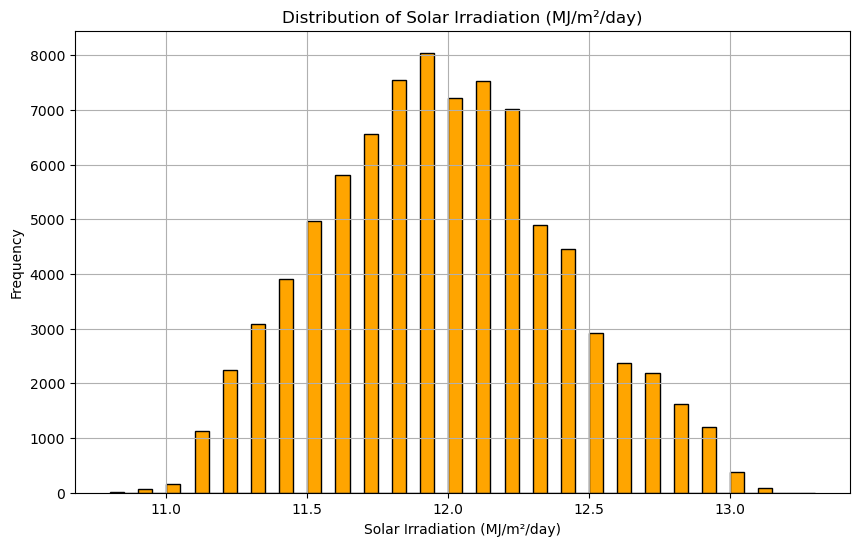

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(irradiation_hokkaido_clean['Solar_Irradiation_MJ'], bins=50, color='orange', edgecolor='black')
plt.title('Distribution of Solar Irradiation (MJ/m²/day)')
plt.xlabel('Solar Irradiation (MJ/m²/day)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

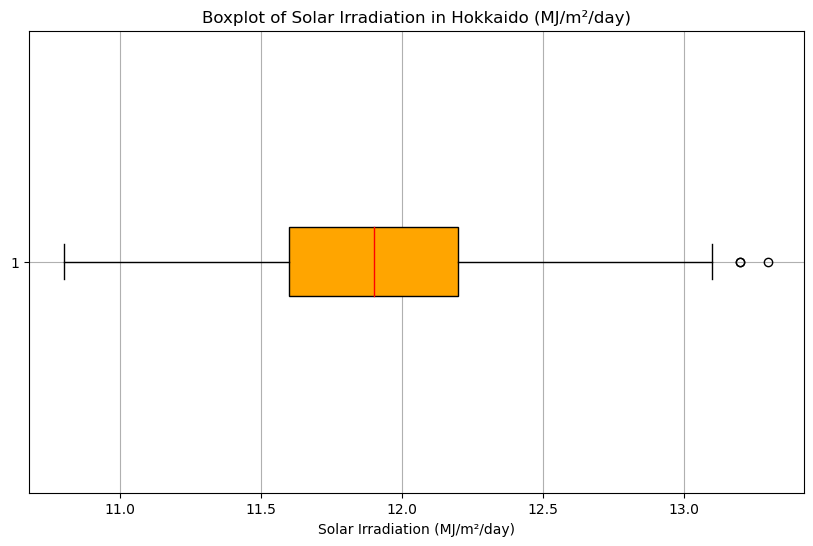

In [29]:
#create boxplot
plt.figure(figsize=(10,6))
plt.boxplot(irradiation_hokkaido_clean['Solar_Irradiation_MJ'], vert=False, patch_artist=True, boxprops=dict(facecolor='orange', color='black'), medianprops=dict(color='red'))
plt.title('Boxplot of Solar Irradiation in Hokkaido (MJ/m²/day)')
plt.xlabel('Solar Irradiation (MJ/m²/day)')
plt.grid()
plt.show()

In [30]:
irradiation_hokkaido_clean.shape

(85434, 3)

In [31]:
irradiation_hokkaido_clean.head()

,G02_084,geometry,Solar_Irradiation_MJ
3269,108,"POLYGON ((140.9875 45.34167, 140.9875 45.35, 1...",10.8
3270,109,"POLYGON ((140.9875 45.35, 140.9875 45.35833, 1...",10.9
3271,110,"POLYGON ((140.9875 45.35833, 140.9875 45.36667...",11.0
3272,108,"POLYGON ((140.975 45.36667, 140.975 45.375, 14...",10.8
3273,111,"POLYGON ((140.9875 45.36667, 140.9875 45.375, ...",11.1


In [32]:
# Create feature_id to have sequential IDs for each row and avoid inconsistency
irradiation_hokkaido_clean = irradiation_hokkaido_clean.reset_index(drop=True)
irradiation_hokkaido_clean['feature_id'] = irradiation_hokkaido_clean.index

In [33]:
irradiation_hokkaido_clean.head()

,G02_084,geometry,Solar_Irradiation_MJ,feature_id
0,108,"POLYGON ((140.9875 45.34167, 140.9875 45.35, 1...",10.8,0
1,109,"POLYGON ((140.9875 45.35, 140.9875 45.35833, 1...",10.9,1
2,110,"POLYGON ((140.9875 45.35833, 140.9875 45.36667...",11.0,2
3,108,"POLYGON ((140.975 45.36667, 140.975 45.375, 14...",10.8,3
4,111,"POLYGON ((140.9875 45.36667, 140.9875 45.375, ...",11.1,4


## AHP PREP


In [34]:
# -- SELECT AREA FROM SRAI --

from srai.regionalizers import geocode_to_region_gdf

# Step 1: Get the boundary for Yamagata prefecture
area = geocode_to_region_gdf("Hokkaido, Japan")
area.crs  # should return EPSG:4326

/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [35]:
#voir sur quel CRS on est
irradiation_hokkaido_clean.crs

<Geographic 2D CRS: EPSG:4612>
Name: JGD2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Japan - onshore and offshore.
- bounds: (122.38, 17.09, 157.65, 46.05)
Datum: Japanese Geodetic Datum 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [36]:
# -- COORDINATE REFERENCE SYSTEM --
# Put both datasets on same CRS (coordinate reference system)   
# OR convert dataset to CRS = 4326 (same as for the regionalizer data sets)
#  Reproject from EPSG:4612 (JGD2000) to EPSG:4326 (WGS84)
irradiation_hokkaido_clean = irradiation_hokkaido_clean.to_crs(epsg=4326)


In [37]:
# -- REGIONALIZER --
# Use Regionalizer from SRAI to regionalize the selected regions in desired resolution with H3Regionalizer 
# (here we chose 7) *we chose resolution 7 because it fits best with mesh 500x500

from srai.regionalizers import H3Regionalizer

# Step 2: Create H3 hexagons for Yamagata
regionalizer = H3Regionalizer(resolution=7)  # resolution 9 = ~500m hexes
regions = regionalizer.transform(area)

regions.head()

,geometry
region_id,
872ee0d8cffffff,"POLYGON ((139.23441 42.27662, 139.23 42.28866,..."
872ea97b3ffffff,"POLYGON ((142.93482 44.68882, 142.93076 44.701..."
872e1a352ffffff,"POLYGON ((141.99436 43.1505, 141.99026 43.1627..."
872e1e6a1ffffff,"POLYGON ((143.32707 42.9119, 143.32317 42.9243..."
872ead542ffffff,"POLYGON ((144.15196 43.72289, 144.14814 43.735..."


In [38]:
regions.shape

(28902, 1)

Step 4 : Scoring system


In [39]:
ahp = irradiation_hokkaido_clean

In [40]:
ahp.head()

,G02_084,geometry,Solar_Irradiation_MJ,feature_id
0,108,"POLYGON ((140.9875 45.34167, 140.9875 45.35, 1...",10.8,0
1,109,"POLYGON ((140.9875 45.35, 140.9875 45.35833, 1...",10.9,1
2,110,"POLYGON ((140.9875 45.35833, 140.9875 45.36667...",11.0,2
3,108,"POLYGON ((140.975 45.36667, 140.975 45.375, 14...",10.8,3
4,111,"POLYGON ((140.9875 45.36667, 140.9875 45.375, ...",11.1,4


In [41]:
def ahp_solar_score(mj_value):
    if mj_value < 11.0:
        return 2
    elif mj_value < 11.3:
        return 3
    elif mj_value < 11.6:
        return 5
    elif mj_value < 12.0:
        return 7
    elif mj_value < 12.5:
        return 9
    else:
        return 10

ahp["ahp_solar_score"] = ahp["Solar_Irradiation_MJ"].apply(ahp_solar_score)


In [42]:
ahp.head()

,G02_084,geometry,Solar_Irradiation_MJ,feature_id,ahp_solar_score
0,108,"POLYGON ((140.9875 45.34167, 140.9875 45.35, 1...",10.8,0,2
1,109,"POLYGON ((140.9875 45.35, 140.9875 45.35833, 1...",10.9,1,2
2,110,"POLYGON ((140.9875 45.35833, 140.9875 45.36667...",11.0,2,3
3,108,"POLYGON ((140.975 45.36667, 140.975 45.375, 14...",10.8,3,2
4,111,"POLYGON ((140.9875 45.36667, 140.9875 45.375, ...",11.1,4,3


step 3 : join 

In [43]:
from srai.joiners import IntersectionJoiner

# Make sure CRS matches!
ahp = ahp.to_crs(regions.crs)

# Step 3: Use IntersectionJoiner to match land cover to hexagons
joiner = IntersectionJoiner()
joined = joiner.transform(regions, ahp)

# Preview the result
joined.head()


Empty DataFrame
Columns: []
Index: [(872ef2873ffffff, 0), (872ef2873ffffff, 1), (872ef2854ffffff, 1), (872ef2854ffffff, 2), (872ef2855ffffff, 3)]

In [44]:
# Bring region_id back as a column
joined = joined.reset_index()


In [45]:
joined.head()

,region_id,feature_id
0,872ef2873ffffff,0
1,872ef2873ffffff,1
2,872ef2854ffffff,1
3,872ef2854ffffff,2
4,872ef2855ffffff,3


In [46]:
#join ahp_solar_score from ahp ro joined dataset aggreagating by average
# Step 1: Merge AHP scores into joined df (match feature_id to its score)
joined_with_scores = joined.merge(ahp[['feature_id', 'ahp_solar_score']], on='feature_id', how='left')


In [47]:
joined_with_scores.head()

,region_id,feature_id,ahp_solar_score
0,872ef2873ffffff,0,2
1,872ef2873ffffff,1,2
2,872ef2854ffffff,1,2
3,872ef2854ffffff,2,3
4,872ef2855ffffff,3,2


In [48]:

# Step 2: Average scores per region_id
hex_scores = joined_with_scores.groupby("region_id")["ahp_solar_score"].mean().reset_index()

# Step 3: Merge into regions GeoDataFrame to keep geometry
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [49]:
regions_scored.head(200)

,region_id,geometry,ahp_solar_score
0,872ee0d8cffffff,"POLYGON ((139.23441 42.27662, 139.23 42.28866,...",NaN
1,872ea97b3ffffff,"POLYGON ((142.93482 44.68882, 142.93076 44.701...",NaN
2,872e1a352ffffff,"POLYGON ((141.99436 43.1505, 141.99026 43.1627...",7.0
3,872e1e6a1ffffff,"POLYGON ((143.32707 42.9119, 143.32317 42.9243...",10.0
4,872ead542ffffff,"POLYGON ((144.15196 43.72289, 144.14814 43.735...",9.0
...,...,...,...
195,872e134c6ffffff,"POLYGON ((145.06449 43.19231, 145.06084 43.204...",9.0
196,872e1e69affffff,"POLYGON ((143.29999 43.04522, 143.29608 43.057...",10.0
197,872ee48aaffffff,"POLYGON ((139.79944 41.29253, 139.79516 41.304...",NaN
198,872e1b980ffffff,"POLYGON ((141.59901 42.58266, 141.59489 42.594...",NaN


In [163]:
# #**** RUN THIS CELL ONLY IF RESOLUTION IS 8 OR HIGHER --> When reso is higher than 7, there will be multiples hexagones inside every mesh (polygone of 250m x 250m) 
## and to get one value per mesh
# Aggregate solar irradiation per hexagon by taking mean
#aggregated = joined_with_tags.groupby('region_id').agg({'Solar_Irradiation_MJ':'mean'}).reset_index()

# Quick check
#aggregated.describe()
#aggregated.head()


In [31]:
#regions_scored save to output *before creating the map 
regions_scored.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_irradiationreso7.geojson", driver="GeoJSON")

In [33]:
from srai.plotting import plot_numeric_data

#remettre le index 
regions_scored = regions_scored.set_index("region_id")

m = plot_numeric_data(regions_scored, "ahp_solar_score", colormap="YlOrRd", opacity=0.6)
m.save("irradiation_hokkaido_map.html")

/tmp/ipykernel_42480/1574423309.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


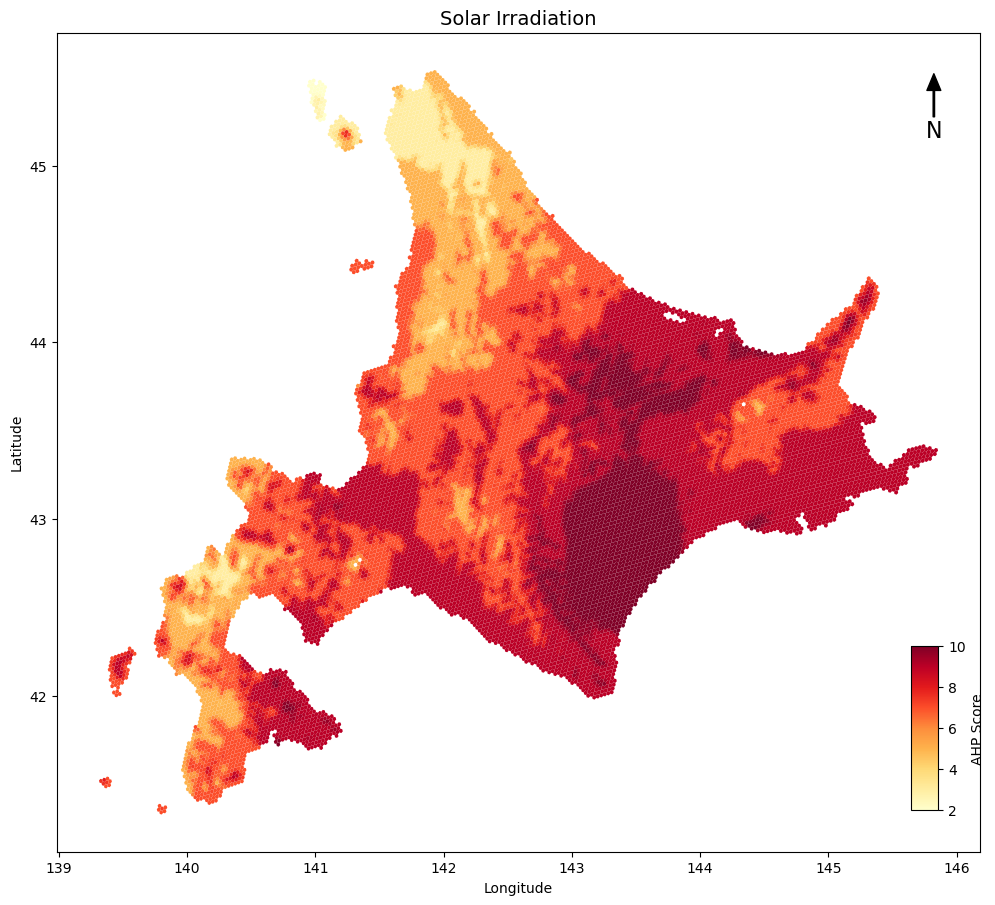

In [54]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = regions_scored.plot(
    column='ahp_solar_score',
    cmap='YlOrRd',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=regions_scored['ahp_solar_score'].min(), vmax=regions_scored['ahp_solar_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("AHP Score")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Solar Irradiation", fontsize=14)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()


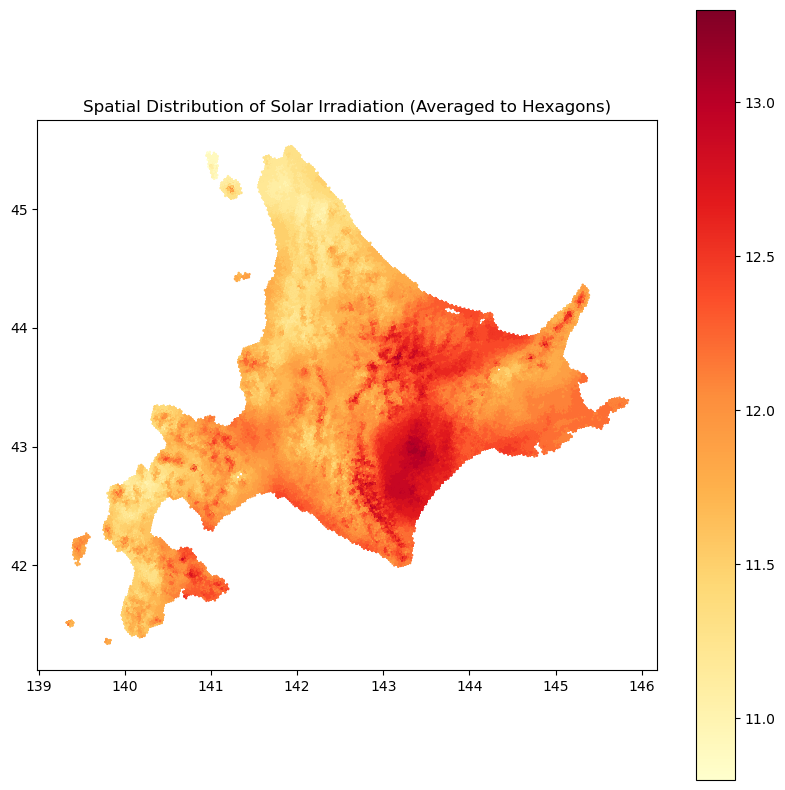

In [164]:
# If you still have 'regions' geodataframe loaded:
regions_with_solar = regions.merge(joined_with_tags, on='region_id')

regions_with_solar.plot(
    column='Solar_Irradiation_MJ',
    cmap='YlOrRd',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of Solar Irradiation (Averaged to Hexagons)")
plt.show()


In [165]:
joined_with_tags.head()

,region_id,feature_id,Solar_Irradiation_MJ
0,872ef2873ffffff,0,10.8
1,872ef2873ffffff,1,10.9
2,872ef2854ffffff,1,10.9
3,872ef2854ffffff,2,11.0
4,872ef2855ffffff,3,10.8


In [166]:
joined_with_tags.shape

(189342, 3)

In [167]:
# print number of missing values 
print("Number of missing values in 'Solar_Irradiation_MJ':", joined_with_tags['Solar_Irradiation_MJ'].isnull().sum())


Number of missing values in 'Solar_Irradiation_MJ': 0


In [170]:
joined_with_tags["ahp_solar_score"] = joined_with_tags["Solar_Irradiation_MJ"].map(ahp_solar_score)


In [171]:
ahp.head()

,G02_084,geometry,Solar_Irradiation_MJ,feature_id,ahp_solar_score
0,108,"POLYGON ((140.9875 45.34167, 140.9875 45.35, 1...",10.8,0,0
1,109,"POLYGON ((140.9875 45.35, 140.9875 45.35833, 1...",10.9,1,0
2,110,"POLYGON ((140.9875 45.35833, 140.9875 45.36667...",11.0,2,3
3,108,"POLYGON ((140.975 45.36667, 140.975 45.375, 14...",10.8,3,0
4,111,"POLYGON ((140.9875 45.36667, 140.9875 45.375, ...",11.1,4,3


In [172]:
hex_scores = joined_with_tags.groupby("region_id")["ahp_solar_score"].mean().reset_index()


In [173]:
hex_scores.head()

,region_id,ahp_solar_score
0,872e122c1ffffff,9.0
1,872e122c3ffffff,9.0
2,872e122c8ffffff,9.0
3,872e122caffffff,9.0
4,872e122cbffffff,9.0


In [174]:
from srai.plotting import plot_numeric_data

#remettre le index 
hex_scores = hex_scores.set_index("region_id")


m = plot_numeric_data(hex_scores, "ahp_solar_score", colormap="YlGnBu", opacity=0.6)
m.save("irradiation_hokkaido_map.html")


KeyError: "None of [Index(['geometry'], dtype='object')] are in the [columns]"

In [ ]:


m = plot_numeric_data(hex_scores, "ahp_solar_score", colormap="YlGnBu", opacity=0.6)
m.save("irradiation_hokkaido_map.html")


In [89]:
hex_scores = joined_with_tags.groupby("region_id")["ahp_solar_score"].mean().reset_index()
hex_scores.columns = ["region_id", "ahp_solar_score"]


In [90]:
# Merge scores into hexagon GeoDataFrame
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [91]:
# Merge scores into hexagon GeoDataFrame
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [92]:
regions_scored.head()

,region_id,geometry,ahp_solar_score
0,872ef4682ffffff,"POLYGON ((141.37268 44.48742, 141.36842 44.499...",NaN
1,872e130f5ffffff,"POLYGON ((144.78401 42.81732, 144.78033 42.829...",NaN
2,872eac382ffffff,"POLYGON ((144.95136 43.88616, 144.94765 43.898...",9.000000
3,872e1aa90ffffff,"POLYGON ((142.31715 43.06565, 142.3131 43.0779...",7.307692
4,872ead82bffffff,"POLYGON ((144.04124 43.10342, 144.03744 43.115...",9.000000


In [93]:
#count number of missing value in regions_scored
missing_count = regions_scored['ahp_solar_score'].isnull().sum()

In [94]:
missing_count

11968

In [96]:
regions_scored.shape

(28902, 3)